In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings, os, urllib.request, time

warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})

# ── Chargement du dataset ─────────────────────────────────────────────────────
r_data = pd.read_csv('global_power_plant_database.csv')

print(f"\nDataset Shape: {r_data.shape}")
print("\nColumn Names:")
print(r_data.columns.tolist())



Dataset Shape: (34936, 36)

Column Names:
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']


In [6]:
r_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

In [7]:
r_data.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [8]:
print("Missing values ​​per column :")
print(r_data.isnull().sum())

Missing values ​​per column :
country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation

In [9]:
print("Duplicated lines :", r_data.duplicated().sum())
r_data = r_data.drop_duplicates()

#  Missing values 
print("\nMissing values after removing duplicates :")
print(r_data.isnull().sum())

if 'Postal Code' in r_data.columns:
    r_data['Postal Code'] = r_data['Postal Code'].fillna(0).astype(str).str.zfill(5)
    print("\nPostal Code : missing values filled with '0'.")

Duplicated lines : 0

Missing values after removing duplicates :
country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_

In [10]:
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in r_data.columns:
        r_data[col] = pd.to_datetime(r_data[col])

print("Types after conversion :")
date_columns = [col for col in ['Order Date', 'Ship Date'] if col in r_data.columns]

if date_columns:
    for col in date_columns:
        r_data[col] = pd.to_datetime(r_data[col])
    print("Types after conversion :")
    print(r_data[date_columns].dtypes)
else:
    print("Warning: Neither 'Order Date' nor 'Ship Date' columns found in the dataset")

Types after conversion :


In [11]:
#  Feature Engineering 
r_data['commissioning_year'] = pd.to_numeric(r_data['commissioning_year'], errors='coerce')
r_data['age'] = 2024 - r_data['commissioning_year']

# Calculate capacity factor if generation data exists
if 'generation_gwh_2019' in r_data.columns:
	r_data['estimated_capacity_factor'] = (r_data['generation_gwh_2019'] * 1000) / (r_data['capacity_mw'] * 8760)

print("New functional features created :")
display(r_data[['name', 'capacity_mw', 'primary_fuel', 'commissioning_year', 'age']].head(6))

print(f"\nQuick Summary :")
print(f"  Total Capacity (MW)          : {r_data['capacity_mw'].sum():,.0f} MW")
print(f"  Average Plant Capacity       : {r_data['capacity_mw'].mean():.1f} MW")
print(f"  Average Age (years)          : {r_data['age'].mean():.1f} years")
print(f"  Power Plants Count           : {len(r_data):,}")

New functional features created :


,name,capacity_mw,primary_fuel,commissioning_year,age
0,Kajaki Hydroelectric Power Plant Afghanistan,33.00,Hydro,NaN,NaN
1,Kandahar DOG,10.00,Solar,NaN,NaN
2,Kandahar JOL,10.00,Solar,NaN,NaN
3,Mahipar Hydroelectric Power Plant Afghanistan,66.00,Hydro,NaN,NaN
4,Naghlu Dam Hydroelectric Power Plant Afghanistan,100.00,Hydro,NaN,NaN
5,Nangarhar (Darunta) Hydroelectric Power Plant ...,11.55,Hydro,NaN,NaN



Quick Summary :
  Total Capacity (MW)          : 5,706,975 MW
  Average Plant Capacity       : 163.4 MW
  Average Age (years)          : 26.6 years
  Power Plants Count           : 34,936


## 2. Analyse avec Matplolib

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from ipywidgets import Dropdown, interact

#  Preparation des donnees temporelles 
if 'r_data' not in globals():
    # If the dataframe was loaded with another name, alias it here
    for candidate_name in ['df', 'data', 'raw_data', 'raw_df', 'dataset', 'candidate']:
        if candidate_name in globals():
            candidate_obj = globals()[candidate_name]
            if isinstance(candidate_obj, str) and candidate_obj in globals():
                candidate_obj = globals()[candidate_obj]
            if isinstance(candidate_obj, pd.DataFrame):
                r_data = candidate_obj
                break
    else:
        dataframe_candidates = [obj for obj in globals().values() if isinstance(obj, pd.DataFrame)]
        if len(dataframe_candidates) == 1:
            r_data = dataframe_candidates[0]
        else:
            raise NameError("r_data is not defined. Load the dataframe first, for example:\n"
                            "r_data = pd.read_csv('your_file.csv')")

if {'Order Month-Year', 'Category', 'Sales'}.issubset(r_data.columns):
    monthly_sales = r_data.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
    monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

    CATEGORY_COLORS = {
        'Furniture': '#E84855',
        'Office Supplies': '#2176AE',
        'Technology': '#3BB273',
        'All': '#7B2D8B'
    }

    def plot_monthly_sales(category='All'):
        fig, ax = plt.subplots(figsize=(13, 6))

        if category == 'All':
            total_monthly = r_data.groupby('Order Month-Year')['Sales'].sum()
            dates = total_monthly.index.to_timestamp()
            values = total_monthly.values
            ax.plot(dates, values, marker='o', linewidth=2, markersize=4,
                    color=CATEGORY_COLORS['All'])
            ax.fill_between(dates, values, alpha=0.1, color=CATEGORY_COLORS['All'])
            ax.set_title('Trend of Monthly Sales — All Categories',
                         fontsize=15, fontweight='bold')
        else:
            cat_data = monthly_sales[monthly_sales['Category'] == category]
            color = CATEGORY_COLORS.get(category, 'steelblue')
            ax.plot(cat_data['Date'], cat_data['Sales'],
                    marker='o', linewidth=2, markersize=4, color=color)
            ax.fill_between(cat_data['Date'], cat_data['Sales'], alpha=0.1, color=color)
            ax.set_title(f'Trend of Monthly Sales — {category}',
                         fontsize=15, fontweight='bold')

        ax.xaxis.set_major_formatter(mticker.DateFormatter('%b %Y'))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Sales ($)', fontsize=12)
        plt.xticks(rotation=45)
        ax.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()

    categories = ['All'] + sorted(r_data['Category'].unique().tolist())
    category_dropdown = Dropdown(options=categories, value='All',
                                 description='Category:',
                                 style={'description_width': 'initial'})
    interact(plot_monthly_sales, category=category_dropdown)

elif {'commissioning_year', 'primary_fuel', 'capacity_mw'}.issubset(r_data.columns):
    r_data['commissioning_year'] = pd.to_numeric(r_data['commissioning_year'], errors='coerce')
    annual_capacity = (r_data.dropna(subset=['commissioning_year'])
                          .groupby(['commissioning_year', 'primary_fuel'])['capacity_mw']
                          .sum()
                          .reset_index(name='capacity_mw'))
    annual_capacity['commissioning_year'] = annual_capacity['commissioning_year'].astype(int)

    CATEGORY_COLORS = {
        'Hydro': '#4C78A8',
        'Solar': '#F28E2B',
        'Wind': '#59A14F',
        'Coal': '#E15759',
        'Gas': '#76B7B2',
        'Oil': '#EDC948',
        'Biomass': '#B07AA1',
        'All': '#7B2D8B'
    }

    def plot_annual_capacity(fuel='All'):
        fig, ax = plt.subplots(figsize=(13, 6))

        if fuel == 'All':
            total_yearly = annual_capacity.groupby('commissioning_year')['capacity_mw'].sum()
            ax.plot(total_yearly.index, total_yearly.values, marker='o', linewidth=2,
                    markersize=4, color=CATEGORY_COLORS['All'])
            ax.fill_between(total_yearly.index, total_yearly.values, alpha=0.1, color=CATEGORY_COLORS['All'])
            ax.set_title('Annual Installed Capacity by Commissioning Year — All Fuels',
                         fontsize=15, fontweight='bold')
            ax.set_ylabel('Total Capacity (MW)', fontsize=12)
        else:
            fuel_data = annual_capacity[annual_capacity['primary_fuel'] == fuel]
            color = CATEGORY_COLORS.get(fuel, 'steelblue')
            ax.plot(fuel_data['commissioning_year'], fuel_data['capacity_mw'],
                    marker='o', linewidth=2, markersize=4, color=color)
            ax.fill_between(fuel_data['commissioning_year'], fuel_data['capacity_mw'],
                            alpha=0.1, color=color)
            ax.set_title(f'Annual Installed Capacity — {fuel}',
                         fontsize=15, fontweight='bold')
            ax.set_ylabel('Capacity (MW)', fontsize=12)

        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} MW'))
        ax.set_xlabel('Commissioning Year', fontsize=12)
        plt.xticks(rotation=45)
        ax.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()

    fuels = ['All'] + sorted(annual_capacity['primary_fuel'].unique().tolist())
    fuel_dropdown = Dropdown(options=fuels, value='All',
                             description='Fuel:',
                             style={'description_width': 'initial'})
    interact(plot_annual_capacity, fuel=fuel_dropdown)
    print("Note: 'Order Month-Year' is missing. Using commissioning_year and primary_fuel instead.")

else:
    print("Cannot plot monthly sales. Missing required columns: 'Order Month-Year', 'Category', 'Sales', and no commissioning_year/primary_fuel/capacity_mw fallback.")


interactive(children=(Dropdown(description='Fuel:', options=('All', 'Biomass', 'Coal', 'Cogeneration', 'Gas', …

Note: 'Order Month-Year' is missing. Using commissioning_year and primary_fuel instead.


In [14]:
# Geographic aggregation 
# Ensure a 'State' column exists (fallback to common geographic columns)
if 'State' not in r_data.columns:
    for cand in ['state', 'State/Province', 'Province', 'province', 'region', 'country_long', 'country']:
        if cand in r_data.columns:
            r_data['State'] = r_data[cand]
            break
    else:
        r_data['State'] = 'Unknown'

# Ensure 'Sales' exists (fallback to sensible numeric columns)
if 'Sales' not in r_data.columns:
    if 'capacity_mw' in r_data.columns:
        r_data['Sales'] = r_data['capacity_mw']
    elif 'generation_gwh_2019' in r_data.columns:
        r_data['Sales'] = r_data['generation_gwh_2019']
    else:
        r_data['Sales'] = 1  # fallback count proxy

# Ensure 'Profit' exists to avoid KeyError later
if 'Profit' not in r_data.columns:
    if 'capacity_mw' in r_data.columns:
        r_data['Profit'] = r_data['capacity_mw']
    elif 'generation_gwh_2019' in r_data.columns:
        r_data['Profit'] = r_data['generation_gwh_2019']
    else:
        r_data['Profit'] = 0

# Aggregate sales by (pseudo-)state
state_sales = r_data.groupby('State')['Sales'].sum().sort_values(ascending=True)
state_profit = r_data.groupby('State')['Profit'].sum()

def plot_top_states(top_n=10):
    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, top_n * 0.5)))
    fig.suptitle(f'Top {top_n} States — Commercial Performance',
                 fontsize=15, fontweight='bold')

    top_states = state_sales.tail(top_n)

    #  Graphic 1 : Sales 
    norm = plt.Normalize(top_states.min(), top_states.max())
    colors = plt.cm.Blues(norm(top_states.values))
    bars = axes[0].barh(range(len(top_states)), top_states.values,
                        color=colors, edgecolor='white')
    axes[0].set_yticks(range(len(top_states)))
    axes[0].set_yticklabels(top_states.index, fontsize=10)
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[0].set_xlabel('Total sales ($)', fontsize=11)
    axes[0].set_title('Sales ranking', fontweight='bold')

    max_val = top_states.max()
    for i, (state, value) in enumerate(top_states.items()):
        axes[0].text(value + max_val * 0.01, i, f'${value:,.0f}',
                     va='center', fontsize=9, fontweight='bold')

    #  Graphic 2 : Profit des memes Etats 
    top_profit = state_profit[top_states.index]
    profit_colors = ['#3BB273' if v > 0 else '#E84855' for v in top_profit.values]
    axes[1].barh(range(len(top_profit)), top_profit.values,
                 color=profit_colors, edgecolor='white')
    axes[1].set_yticks(range(len(top_profit)))
    axes[1].set_yticklabels(top_profit.index, fontsize=10)
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[1].set_xlabel('Total Profit ($)', fontsize=11)
    axes[1].set_title('Profit corresponding (green=gain, red=loss)', fontweight='bold')
    axes[1].axvline(0, color='black', linewidth=0.8)

    axes[0].grid(axis='x', alpha=0.25)
    axes[1].grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"States analyzed : {len(state_sales)}")
    print(f"Top {top_n} states represent : ${top_states.sum():,.0f} in sales "
          f"({top_states.sum()/state_sales.sum()*100:.1f}% of the total)")

# ── Widget cursor ────────────────────────────────────────────────────────────
top_n_slider = IntSlider(min=5, max=25, value=10,
                         description='Top N States:',
                         style={'description_width': 'initial'})
interact(plot_top_states, top_n=top_n_slider);


interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5, style=SliderStyle(descri…

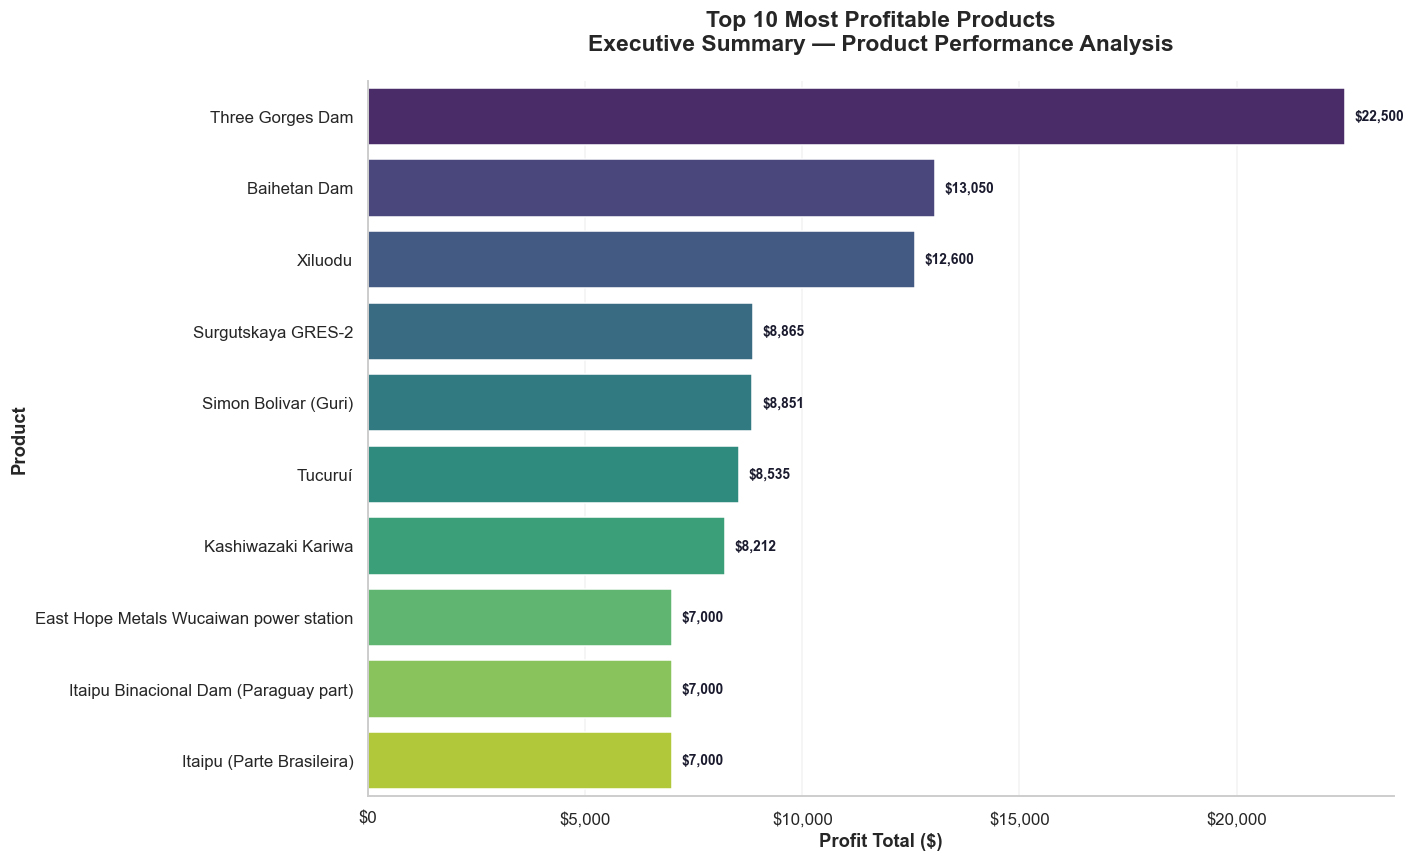

Insights cles :
  Product 1 (profit)             : $22,500
  Contribution Top 10 to profit    : $103,613
  Average profit Top 10              : $10,361
  Share of Top 10 / total profit   : 1.8%


In [16]:
# Top 10 produits par profit 
product_profit = (r_data.groupby('name')['Profit']
                    .sum()
                    .sort_values(ascending=False)
                    .head(10))

# Noms courts pour la lisibilite
short_names = [name[:45] + '...' if len(name) > 45 else name
               for name in product_profit.index]

fig, ax = plt.subplots(figsize=(13, 8))
sns.barplot(x=product_profit.values, y=short_names,
            palette='viridis', orient='h', ax=ax)

ax.set_title('Top 10 Most Profitable Products\nExecutive Summary — Product Performance Analysis',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Profit Total ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.25)

max_val = product_profit.max()
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + max_val * 0.01, i, f'${profit:,.0f}',
            va='center', fontweight='bold', fontsize=9, color='#1A1A2E')

plt.tight_layout()
plt.savefig('fig_top10_profitable.png', dpi=130, bbox_inches='tight')
plt.show()

print("Insights cles :")
print(f"  Product 1 (profit)             : ${product_profit.iloc[0]:,.0f}")
print(f"  Contribution Top 10 to profit    : ${product_profit.sum():,.0f}")
print(f"  Average profit Top 10              : ${product_profit.mean():,.0f}")
print(f"  Share of Top 10 / total profit   : {product_profit.sum()/r_data['Profit'].sum()*100:.1f}%")


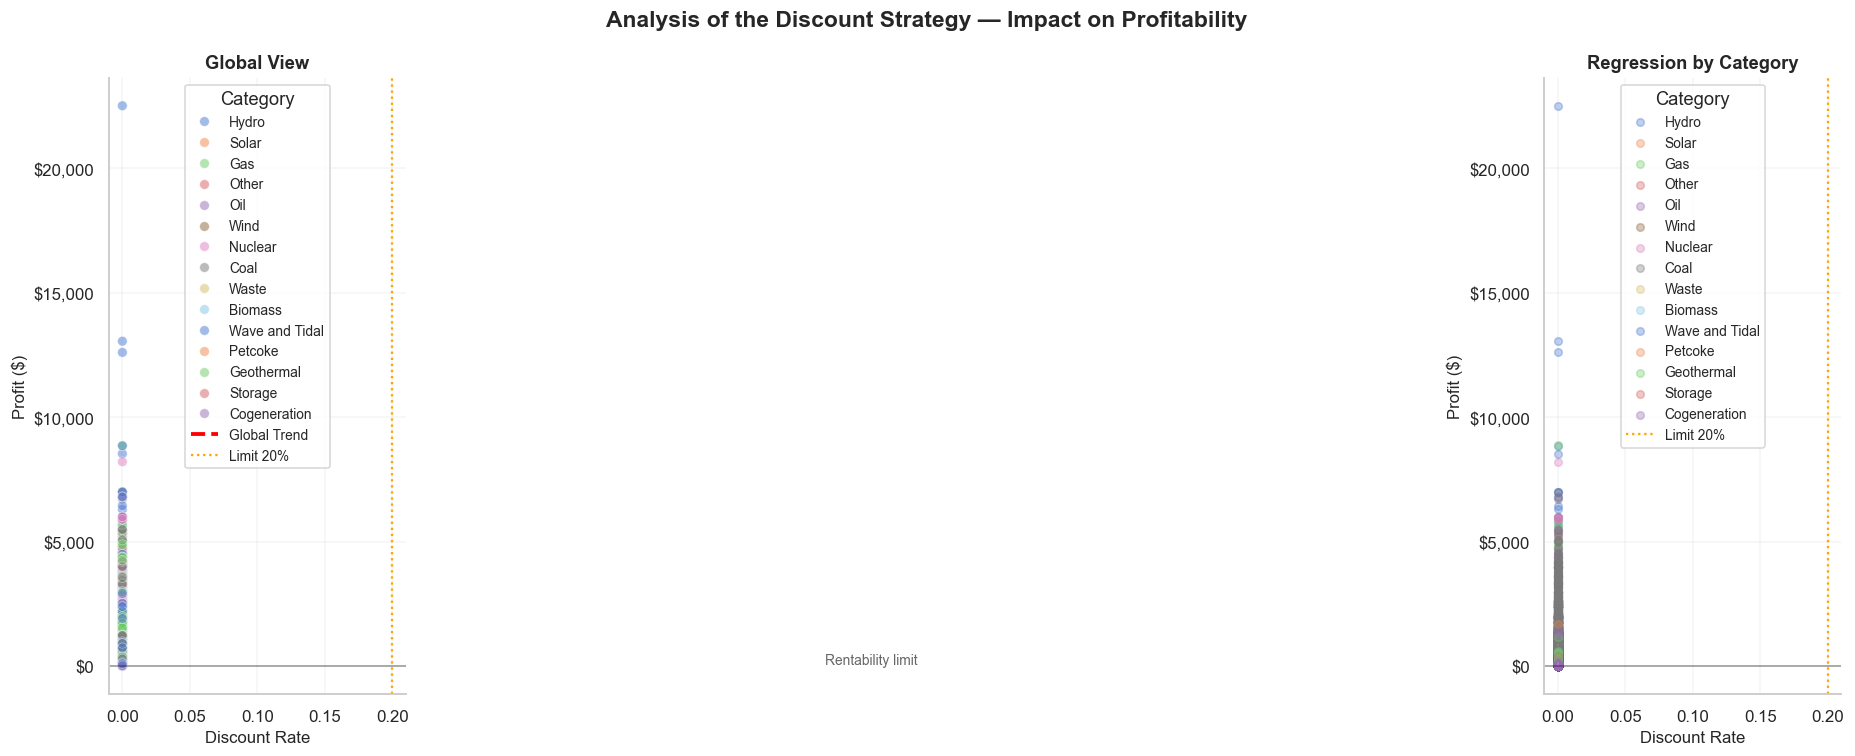

Discount Analysis :
  Transactions with discount > 20%     : 0
  Medium (discount > 20%)        : $nan
  % of losses (discount > 20%)         : nan%
 Discount-Profit Correlation       : nan

Impact by category (discount > 20%) :


In [18]:
# Scatter Discount vs Profit 

from matplotlib.colors import to_hex

# Ensure Discount column exists (create a sensible proxy if missing)
if 'Discount' not in r_data.columns:
    if {'Sales', 'Profit'}.issubset(r_data.columns):
        # proxy: fraction of Sales not converted to Profit (clipped to [0,1])
        r_data['Discount'] = ((r_data['Sales'] - r_data['Profit']) / r_data['Sales']).fillna(0).clip(lower=0)
    else:
        r_data['Discount'] = 0.0

# Ensure Category column exists (fallback to primary_fuel or a default)
if 'Category' not in r_data.columns:
    if 'primary_fuel' in r_data.columns:
        r_data['Category'] = r_data['primary_fuel'].fillna('Unknown')
    else:
        r_data['Category'] = 'Unknown'

# Build a color palette for available categories
unique_cats = r_data['Category'].unique().tolist()
palette = sns.color_palette('muted', n_colors=max(1, len(unique_cats)))
cat_pal = dict(zip(unique_cats, [to_hex(c) for c in palette[:len(unique_cats)]]))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Analysis of the Discount Strategy — Impact on Profitability',
             fontsize=15, fontweight='bold')

#  Graphic 1 : Global view
sns.scatterplot(data=r_data, x='Discount', y='Profit', hue='Category',
                palette=cat_pal, alpha=0.5, s=40, ax=axes[0])
sns.regplot(data=r_data, x='Discount', y='Profit', scatter=False, ax=axes[0],
            color='red', line_kws={'linewidth': 2.5, 'linestyle': '--'},
            label='Global Trend')
axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)
axes[0].text(0.52, 80, 'Rentability limit', fontsize=9, alpha=0.7)
axes[0].axvline(x=0.2, color='orange', linestyle=':', linewidth=1.5,
                label='Limit 20%')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_title('Global View', fontweight='bold')
axes[0].set_xlabel('Discount Rate', fontsize=11)
axes[0].set_ylabel('Profit ($)', fontsize=11)
axes[0].legend(title='Category', fontsize=9)
axes[0].grid(True, alpha=0.2)

# ── Graphique 2 : Par categorie (regression separee) ─────────────────────────
for cat, color in cat_pal.items():
    cat_data = r_data[r_data['Category'] == cat]
    if len(cat_data) == 0:
        continue
    sns.regplot(data=cat_data, x='Discount', y='Profit', scatter=True, ax=axes[1],
                color=color, label=cat,
                scatter_kws={'alpha': 0.35, 's': 25},
                line_kws={'linewidth': 2.2})
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)
axes[1].axvline(x=0.2, color='orange', linestyle=':', linewidth=1.5, label='Limit 20%')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('Regression by Category', fontweight='bold')
axes[1].set_xlabel('Discount Rate', fontsize=11)
axes[1].set_ylabel('Profit ($)', fontsize=11)
axes[1].legend(title='Category', fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('fig_discount_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

# Statistiques analytiques 
print("Discount Analysis :")
high_discount = r_data[r_data['Discount'] > 0.2]
print(f"  Transactions with discount > 20%     : {len(high_discount):,}")
print(f"  Medium (discount > 20%)        : ${high_discount['Profit'].mean():.2f}")
print(f"  % of losses (discount > 20%)         : {(high_discount['Profit'] < 0).mean()*100:.1f}%")

corr = r_data['Discount'].corr(r_data['Profit'])
print(f" Discount-Profit Correlation       : {corr:.4f}")

print("\nImpact by category (discount > 20%) :")
for cat in r_data['Category'].unique():
    cat_hd = r_data[(r_data['Category'] == cat) & (r_data['Discount'] > 0.2)]
    if len(cat_hd) > 0:
        loss_pct = (cat_hd['Profit'] < 0).mean() * 100
        avg_p    = cat_hd['Profit'].mean()
        print(f"  {cat:<20} : medium profit = ${avg_p:>8.2f}  |  {loss_pct:.1f}% of losses")
